THIẾT LẬP HÀM HUẤN LUYỆN

In [1]:
import numpy as np
from scipy.sparse import issparse
import matplotlib.pyplot as plt

In [11]:
class SVMFromScratch:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = 0
        self.epoch_log = [] # Lưu số epoch đã chạy
        self.loss_log = [] # Lưu giá trị loss sau mỗi epoch để theo dõi quá trình hội tụ

    def fit(self, X, y):
        """
        Huấn luyện mô hình SVM sử dụng Stochastic Gradient Descent (SGD).
        X: sparse (scipy sparse matrix).
        y: nhãn lớp, được chuyển đổi thành -1 và 1.
        Thuật toán:
        1. Khởi tạo trọng số w và bias b.
        2. Với mỗi epoch:
           - Với mỗi mẫu x_i:
             - Tính decision = w.x_i + b.
             - Nếu y_i * decision >= 1: cập nhật w và b theo hướng giảm thiểu regularization.
             - Ngược lại: cập nhật w và b theo hướng giảm thiểu cả regularization và hinge loss.
        3. Tính loss sau mỗi epoch để theo dõi quá trình hội tụ.
        """
        n_samples, n_features = X.shape
        # Chuyển nhãn từ 0/1 thành -1/1 để phù hợp với công thức SVM
        # np.where giúp tránh việc tạo một mảng mới nếu y đã ở dạng -1/1
        y_transformed = np.where(y <= 0, -1, 1)

        # Khởi tạo trọng số w và bias b 
        # self.w là vector có kích thước bằng số đặc trưng, khởi tạo bằng 0 --> là Dense Array gồm 10000 phần tử
        self.w = np.zeros(n_features)
        self.b = 0

        self.epoch_log = []
        self.loss_log  = []

        for epoch in range(self.n_iters):
            total_loss = 0

            # Xử lý từng dòng của ma trận sparse để tránh việc chuyển toàn bộ ma trận sang dense --> tiết kiệm bộ nhớ
            for idx in range(n_samples):
                # Lấy từng hàng — vẫn là sparse row
                x_i = X[idx]

                """
                Tính decision value: w.x_i + b.
                    x_i.dot(self.w): lấy vecto dòng x_i (chứa điểm TF-IDF) nhân vô hướng với vecto trọng số self.w --> trả về ma trận 1x1 có dạng [[value]]
                    np.asarray() chuyển ma trận 1x1 thành mảng numpy, 
                    ravel() làm phẳng mảng thành vector 1D dạng [value],
                    [0] lấy giá trị đầu tiên.
                    + self.b: cộng thêm bias.
                """
                decision = np.asarray(x_i.dot(self.w)).ravel()[0] + self.b
                condition = y_transformed[idx] * decision >= 1

                # Nếu điều kiện >= 1, điểm này đã được phân loại đúng với margin, chỉ cần cập nhật regularization.
                if condition:
                    # Cập nhật trọng số w chỉ dựa trên regularization --> mục tiêu đưa trọng số giảm dần về 0
                    # CT: w = w - learning_rate * (2 * lambda_param * w)
                    self.w -= self.learning_rate * (2 * self.lambda_param * self.w)
                
                # Ngược lại, nếu điều kiện < 1, điểm này bị phân loại sai hoặc nằm trong margin, cần cập nhật cả regularization và hinge loss.
                else:
                    """
                    Vì ta sẽ lấy mảng đặc (self.w) nhân với một hàng của ma trận sparse (x_i), 
                    --> Ta cần chuyển hàng đó thành mảng đặc để thực hiện phép nhân vô hướng.
                    x_i.toarray() chuyển hàng sparse thành mảng 2D có một hàng,
                    ravel() làm phẳng thành vector 1D.
                    """
                    x_i_dense = x_i.toarray().ravel() if issparse(x_i) else x_i
                    # CT: w = w - learning_rate * (2 * lambda_param * w - x_i_dense * y_transformed[idx])
                    self.w -= self.learning_rate * (
                        2 * self.lambda_param * self.w - x_i_dense * y_transformed[idx]
                    )
                    #CT: b = b + learning_rate * y_transformed[idx]
                    self.b += self.learning_rate * y_transformed[idx]
                    # Hinge loss của mẫu này
                    total_loss += max(0, 1 - y_transformed[idx] * decision)

            # Tính các chỉ số sau mỗi epoch
            """
            Trong sách giáo khoa: CT: J(w, b) = 1/2 * ||w||^2 + C * sum(max(0, 1 - y_i * (w.x_i + b)))
            Nhưng ở đây lại áp dụng CT: J(w, b) = sum(max(0, 1 - y_i * (w.x_i + b))) / n_samples + lambda_param * ||w||^2
                Đồng thời việc chia trung bình loss trên số mẫu n_samples giúp cho giá trị loss ổn định hơn khi số lượng mẫu thay đổi,
                Trong đó:
                - Loss: tổng hinge loss của tất cả các mẫu trong epoch.
            Điểm khác biệt là giữa hai công thức là hệ số C và lamdba_param
                Về bản chất chúng tương đương nhau. Nhưng C và lamdba_param có mối quan hệ nghịch đảo: C = 1 / (n_samples * lambda_param)
                Nên khi C càng lớn càng phạt nặng lỗi, C càng nhỏ càng phạt nhẹ lỗi.  
                Ngược lại,  lambda_param càng lớn càng phạt nặng trọng số khiến margin hẹp --> Overfitting, 
                            lambda_param càng nhỏ càng phạt nhẹ trọng số khiến margin rộng --> Underfitting.
            """
            total_loss = total_loss / n_samples + self.lambda_param * np.dot(self.w, self.w)

            # Log mỗi 10 epoch
            if (epoch + 1) % 1 == 0 or epoch == 0:
                print(f"{epoch+1:>4} | {total_loss: .4f}")
                self.epoch_log.append(epoch + 1)
                self.loss_log.append(total_loss)

        print("Huấn luyện thành công!")

    def predict(self, X):
        """
        Dự đoán nhãn cho dữ liệu đầu vào X.
        X: sparse (scipy sparse matrix).
        Thuật toán:
            1. Tính linear_output = X.dot(w) + b.
            - X.dot(w) hoạt động trực tiếp với sparse matrix, trả về một vector kết quả có kích thước bằng số mẫu, mỗi phần tử là kết quả của w.x_i.
            2. Sử dụng np.sign để xác định dấu của linear_output:
                - Nếu linear_output > 0, np.sign trả về 1 (dự đoán lớp dương).
                - Nếu linear_output <= 0, np.sign trả về 0 (dự đoán lớp âm).
            3. Trả về mảng dự đoán nhãn (0 hoặc 1) tương ứng với từng mẫu trong X.
                - Nếu dấu dương, trả về 1 --> Spam
                - Nếu dấu âm hoặc bằng 0, trả về 0. --> Not Spam
        """
        # X.dot(self.w) hoạt động trực tiếp với sparse matrix
        linear_output = np.asarray(X.dot(self.w)).ravel() + self.b
        return np.where(np.sign(linear_output) > 0, 1, 0)
    
    def plot_loss(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.epoch_log, self.loss_log,
                 color='steelblue', linewidth=2, marker='o', markersize=3)
        plt.title('Quá trình hội tụ của mô hình SVM', fontsize=14, fontweight='bold')
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

LẤY DỮ LIỆU TRAIN/TEST và BẮT ĐẦU HUẤN LUYỆN

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [42]:
# BƯỚC 1: ĐỌC DỮ LIỆU THÔ TỪ FILE CSV
print("Bắt đầu đọc dữ liệu từ các file CSV...")

train_df = pd.read_csv('train_raw.csv')
test_df  = pd.read_csv('test_raw.csv')

X_train_raw = train_df['text'].values
X_test_raw  = test_df['text'].values

# Chuyển cột 'spam' thành mảng numpy để dễ dàng xử lý sau này
y_train     = np.array(train_df['spam'].values) 
y_test      = np.array(test_df['spam'].values) 

print(f"Đã nạp dữ liệu thành công!")
print(f"Tập Train: {len(X_train_raw)} mẫu  |  Spam: {y_train.sum()}  |  Ham: {len(y_train) - y_train.sum()}")
print(f"Tập Test : {len(X_test_raw)} mẫu  |  Spam: {y_test.sum()}  |  Ham: {len(y_test) - y_test.sum()}")


# BƯỚC 2: TF-IDF VECTORIZATION (chuyển text → ma trận số)
print("\nĐang áp dụng TF-IDF Vectorization...")

tfidf = TfidfVectorizer(
    max_features=1500,      # Giữ 1.500 từ phổ biến nhất
    sublinear_tf=True,       # Dùng log(tf) — giảm ảnh hưởng từ lặp nhiều
    strip_accents='unicode', # Loại bỏ dấu tiếng Việt để chuẩn hóa từ
    analyzer='word',         # Phân tích ở mức từ (không phải ký tự) để giữ nguyên ý nghĩa   
    token_pattern=r'\w{2,}', # Bỏ ký tự đơn, giữ từ ≥ 2 ký tự
    ngram_range=(1, 2),      # Unigram + Bigram để bắt ngữ cảnh
    min_df=2,                # Bỏ từ chỉ xuất hiện trong 1 email
)

# Quan trọng: chỉ fit trên TRAIN, transform TEST — tránh data leakage
X_train = tfidf.fit_transform(X_train_raw) # Chuyển văn bản thô thành ma trận TF-IDF sparse, dùng cho tập Train 
X_test  = tfidf.transform(X_test_raw) # Chuyển văn bản thô thành ma trận TF-IDF sparse, nhưng không fit lại để tránh data leakage, dùng cho tập Test

print(f"Kích thước tập Train sau TF-IDF: {X_train.shape}")
print(f"Kích thước tập Test  sau TF-IDF: {X_test.shape}")

# Kiểm tra mật độ của ma trận sparse để đảm bảo rằng nó thực sự sparse (nhiều phần tử bằng 0)
print(f"Mật độ sparse matrix: {X_train.nnz / (X_train.shape[0] * X_train.shape[1]) * 100:.2f}%") 

# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH SVM
print("\nĐang tiến hành huấn luyện mô hình SVM từ gốc...")
svm = SVMFromScratch(learning_rate=0.01, lambda_param=0.001, n_iters=40)
svm.fit(X_train, y_train)

Bắt đầu đọc dữ liệu từ các file CSV...
Đã nạp dữ liệu thành công!
Tập Train: 4396 mẫu  |  Spam: 1093  |  Ham: 3303
Tập Test : 1100 mẫu  |  Spam: 273  |  Ham: 827

Đang áp dụng TF-IDF Vectorization...
Kích thước tập Train sau TF-IDF: (4396, 1500)
Kích thước tập Test  sau TF-IDF: (1100, 1500)
Mật độ sparse matrix: 6.65%

Đang tiến hành huấn luyện mô hình SVM từ gốc...
   1 |  0.4656
   2 |  0.3819
   3 |  0.3209
   4 |  0.2736
   5 |  0.2458
   6 |  0.2325
   7 |  0.2260
   8 |  0.2220
   9 |  0.2191
  10 |  0.2169
  11 |  0.2152
  12 |  0.2140
  13 |  0.2131
  14 |  0.2123
  15 |  0.2118
  16 |  0.2113
  17 |  0.2108
  18 |  0.2104
  19 |  0.2102
  20 |  0.2099
  21 |  0.2098
  22 |  0.2096
  23 |  0.2096
  24 |  0.2093
  25 |  0.2093
  26 |  0.2092
  27 |  0.2091
  28 |  0.2092
  29 |  0.2090
  30 |  0.2089
  31 |  0.2090
  32 |  0.2089
  33 |  0.2090
  34 |  0.2088
  35 |  0.2089
  36 |  0.2090
  37 |  0.2088
  38 |  0.2088
  39 |  0.2088
  40 |  0.2088
Huấn luyện thành công!


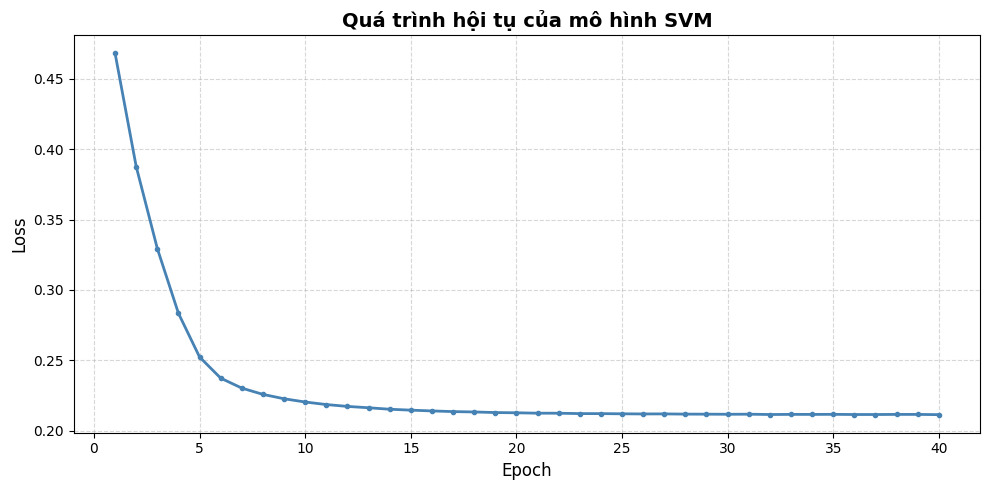

In [35]:
svm.plot_loss()

THIẾT LẬP HÀM TEST BẰNG CÁC THƯỚC ĐO

In [20]:
def evaluate_model_comprehensive(y_true, y_pred):
    """
    Hàm tính toán toàn bộ các chỉ số hiệu năng từ gốc.
    Quy ước nhãn theo code trước: 1 là Spam (Positive), 0 là không Spam (Negative).
    """
    # Ép kiểu dữ liệu về dạng mảng phẳng Numpy để tính toán toán học
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 1. Tính toán các thành phần của Ma trận nhầm lẫn (Confusion Matrix)
    TP = np.sum((y_true == 1) & (y_pred == 1)) # Thực tế là Spam, đoán đúng là Spam
    FP = np.sum((y_true == 0) & (y_pred == 1)) # Thực tế là không Spam, đoán sai thành Spam (Báo động giả!)
    TN = np.sum((y_true == 0) & (y_pred == 0)) # Thực tế là không Spam, đoán đúng là không Spam
    FN = np.sum((y_true == 1) & (y_pred == 0)) # Thực tế là Spam, đoán sai thành không Spam (Lọt lưới!)

    print("--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
    print(f"True Positive (Bắt trúng Spam) : {TP}")
    print(f"False Positive (Chặn nhầm không Spam): {FP}")
    print(f"True Negative (Giữ đúng không Spam)  : {TN}")
    print(f"False Negative (Lọt lưới Spam) : {FN}\n")

    # 2. Tính toán các chỉ số (Thêm điều kiện tránh lỗi chia cho 0)
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0 # Tỷ lệ dự đoán đúng trên tổng số mẫu
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0 # Tỷ lệ dự đoán đúng trên tổng số mẫu được dự đoán là Spam
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0 # Tỷ lệ dự đoán đúng trên tổng số mẫu thực sự là Spam
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0 # Cân bằng giữa Precision và Recall, đặc biệt hữu ích khi dữ liệu bị lệch (imbalanced)
    
    # Chỉ số bổ sung nâng cao
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0 # Tỷ lệ bảo vệ đúng không Spam
    fpr = FP / (TN + FP) if (TN + FP) > 0 else 0 # Tỷ lệ chặn nhầm không Spam (False Positive Rate)
    
    # Tính toán Matthews Correlation Coefficient (MCC)
    mcc_denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)) 
    mcc = (TP * TN - FP * FN) / mcc_denominator if mcc_denominator > 0 else 0 # Thang đo từ -1 đến 1, càng gần 1 càng tốt, gần 0 là ngẫu nhiên, gần -1 là tệ

    # 3. Xuất kết quả trực quan
    print("--- CÁC CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG ---")
    print(f"1. Accuracy (Độ chính xác tổng thể)      : {accuracy * 100:.2f}%")
    print(f"2. Precision (Độ chuẩn xác bắt Spam)     : {precision * 100:.2f}%")
    print(f"3. Recall (Độ nhạy / Tỷ lệ bắt sạch Spam): {recall * 100:.2f}%")
    print(f"4. F1-Score (Cân bằng giữa Prec & Rec)   : {f1_score * 100:.2f}%")
    print(f"5. Specificity (Tỷ lệ bảo vệ Ham đúng)   : {specificity * 100:.2f}%")
    print(f"6. False Positive Rate (Tỷ lệ chặn nhầm) : {fpr * 100:.2f}%  <-- Càng gần 0% càng tốt")
    print(f"7. Matthews Correlation Coefficient (MCC): {mcc:.4f}  (Thang đo từ -1 đến 1)")

    return {
        "accuracy": accuracy, "precision": precision, "recall": recall, 
        "f1_score": f1_score, "specificity": specificity, "fpr": fpr, "mcc": mcc
    }

BẮT ĐẦU TEST

In [43]:
y_pred = svm.predict(X_test)
metrics = evaluate_model_comprehensive(y_test, y_pred)

--- MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
True Positive (Bắt trúng Spam) : 254
False Positive (Chặn nhầm không Spam): 4
True Negative (Giữ đúng không Spam)  : 823
False Negative (Lọt lưới Spam) : 19

--- CÁC CHỈ SỐ ĐÁNH GIÁ HIỆU NĂNG ---
1. Accuracy (Độ chính xác tổng thể)      : 97.91%
2. Precision (Độ chuẩn xác bắt Spam)     : 98.45%
3. Recall (Độ nhạy / Tỷ lệ bắt sạch Spam): 93.04%
4. F1-Score (Cân bằng giữa Prec & Rec)   : 95.67%
5. Specificity (Tỷ lệ bảo vệ Ham đúng)   : 99.52%
6. False Positive Rate (Tỷ lệ chặn nhầm) : 0.48%  <-- Càng gần 0% càng tốt
7. Matthews Correlation Coefficient (MCC): 0.9436  (Thang đo từ -1 đến 1)
